# Buildinga a Feedforward Neural Network from Scratch in Python

## Keras

Keras is a high-level neural networks API, written in Python and capable of running on top of TensorFlow, Microsoft Cognitive Toolkit, Theano, or PlaidML. It was developed with a focus on enabling fast experimentation and is designed to be user-friendly, modular, and extensible.
> Keras is good for beginners because it provides a simple and intuitive interface for building and training neural networks. It abstracts away much of the complexity of deep learning, allowing users to focus on designing and experimenting with models rather than dealing with low-level details. But nowadays, PyTorch is the most popular framework for real-world applications.

## Load dataset

We will use Keras to build and train a simple feedforward neural network on the [CIFAR-10 dataset](https://www.cs.toronto.edu/~kriz/cifar.html), which consists of 60,000 32x32 color images in 10 different classes.

In [1]:
from keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

2025-12-23 18:04:10.579471: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-23 18:04:10.608306: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-23 18:04:11.662283: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-23 18:04:15.268875: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

> https://keras.io/api/datasets/cifar10/

> To avoid reloading, we could set KERAS_HOME to a local directory and store the dataset there.

We check dataset size

In [21]:
print(f'Training data shape: {x_train.shape}, Training labels shape: {y_train.shape}')
print(f'Testing data shape: {x_test.shape}, Testing labels shape: {y_test.shape}')
print(f'Percentage of training data used: {len(x_train) / (len(x_train) + len(x_test)) * 100:.2f}%')
print(f'Percentage of testing data used: {len(x_test) / (len(x_train) + len(x_test)) * 100:.2f}%')

Training data shape: (50000, 32, 32, 3), Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3), Testing labels shape: (10000, 1)
Percentage of training data used: 83.33%
Percentage of testing data used: 16.67%


The dataset has 50,000 training images and 10,000 testing images.

In [22]:
num_classes = len(set(y_train.flatten()))
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(num_classes):
    print(f'Number of images in {class_names[i]}: {len(y_train[y_train == i])}')

Number of images in airplane: 5000
Number of images in automobile: 5000
Number of images in bird: 5000
Number of images in cat: 5000
Number of images in deer: 5000
Number of images in dog: 5000
Number of images in frog: 5000
Number of images in horse: 5000
Number of images in ship: 5000
Number of images in truck: 5000


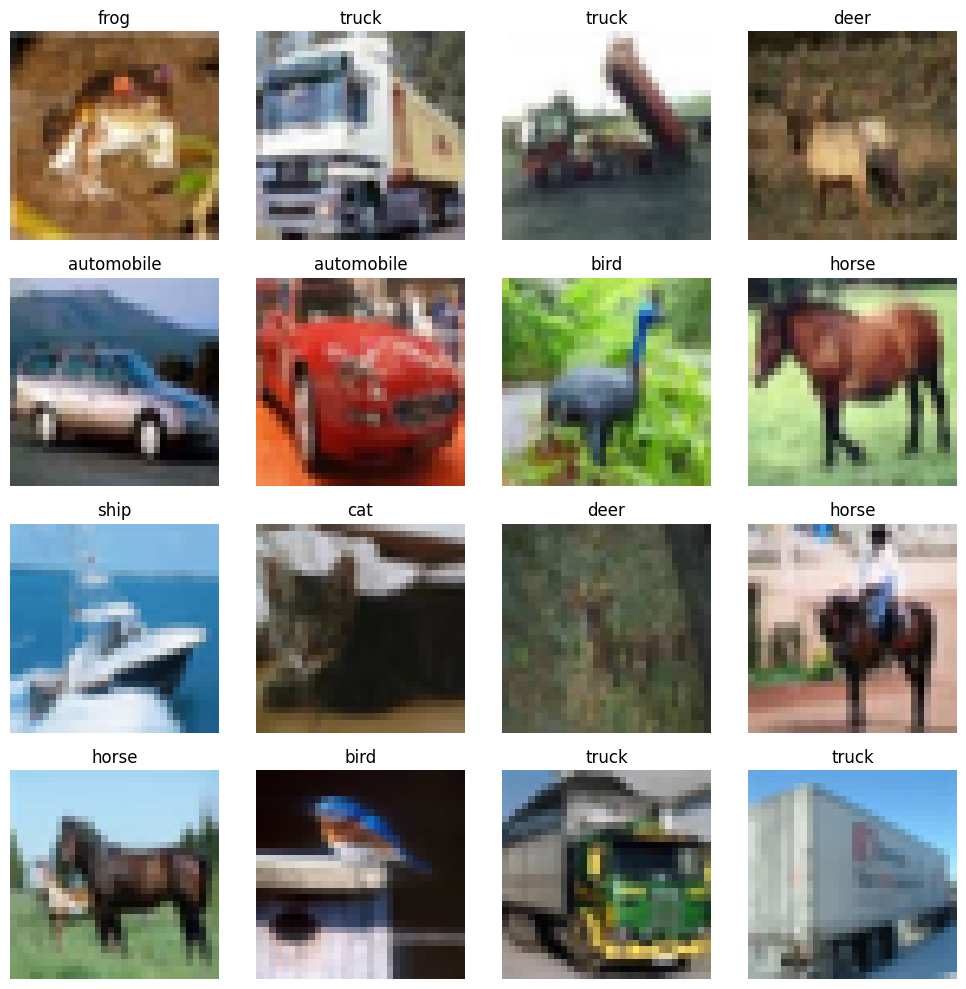

In [23]:
from matplotlib import pyplot as plt

def plot_grid(x, y, grid_size, class_names):
	"""Display a grid of images with their labels"""
	fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
	for i in range(grid_size):
		for j in range(grid_size):
			idx = i * grid_size + j
			axes[i, j].imshow(x[idx])
			axes[i, j].set_title(class_names[y[idx][0]])
			axes[i, j].axis('off')
	plt.tight_layout()
	plt.show()

plot_grid(x_train, y_train, 4, class_names)

### Prepare the Dataset

We will prepare the dataset by normalizing the pixel values and converting the labels to one-hot encoding.
> Images have pixel values ranging from 0 to 255. Normalizing these values to a range of 0 to 1 helps improve the convergence of the neural network during training.

In [24]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

We convert each image from a 32x32x3 array to a 3072-dimensional vector (32 * 32 * 3 = 3072) to feed into the feedforward neural network.
> numpy will calculate the size automatically with -1

In [25]:
X_train = x_train.reshape((x_train.shape[0], -1))
X_test = x_test.reshape((x_test.shape[0], -1))

Finally, we adjust our labels from 0-9 to one-hot encoded vectors.
> We can use sklearn's LabelBinarizer or Keras's to_categorical for this task.

In [26]:
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
y_train = lb.fit_transform(y_train)
y_test = lb.transform(y_test)

print(f'New structure for labels: {y_train[0]}')

New structure for labels: [0 0 0 0 0 0 1 0 0 0]


This way the output layer of our neural network can have 10 neurons, each representing a class, and the target output for each image will be a vector with a 1 in the position corresponding to the correct class and 0s elsewhere.

### Design of the Neural Network

- Input Layer: 3072 neurons (one for each pixel in the flattened image)
- Output Layer: 10 neurons (one for each class in CIFAR-10)
- Activation Function: We have a multi-class classification problem, so we will use the softmax activation function in the output layer to get probabilities for each class.

In [ ]:
from keras.models import Sequential
from keras.layers import Input, Dense

# We build the feedforward neural network
model = Sequential()
model.add(Input(shape=(3072,)))  # Input layer
model.add(Dense(1024, activation='relu'))  # Hidden layer with 1024 neurons
model.add(Dense(512, activation='relu'))   # Hidden layer with 512 neurons
model.add(Dense(10, activation='softmax'))  # Output layer with 10 neurons for 10 classes

Number of hidden layers and neurons per layer can be adjusted based on experimentation and performance on validation data.

Now we choose our optimizer, loss function and metrics to compile the model.
> We will use Stochastic Gradient Descent (SGD) as the optimizer, categorical crossentropy as the loss function (suitable for multi-class classification), and accuracy as the evaluation metric.

Finally, we train the model on the training data and evaluate its performance on the test data.

> Epoch and batch size can be adjusted based on experimentation and performance on validation data.

In [30]:
from keras.optimizers import SGD

opt = SGD(learning_rate=0.01)

model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
H = model.fit(X_train, y_train, epochs=50, batch_size=150, validation_data=(X_test, y_test)) 

Epoch 1/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.3063 - loss: 1.9638 - val_accuracy: 0.3481 - val_loss: 1.8684
Epoch 2/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.3695 - loss: 1.7981 - val_accuracy: 0.3570 - val_loss: 1.7958
Epoch 3/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.3958 - loss: 1.7309 - val_accuracy: 0.3926 - val_loss: 1.7262
Epoch 4/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.4124 - loss: 1.6815 - val_accuracy: 0.3854 - val_loss: 1.7229
Epoch 5/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.4278 - loss: 1.6412 - val_accuracy: 0.4040 - val_loss: 1.6731
Epoch 6/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.4357 - loss: 1.6118 - val_accuracy: 0.4166 - val_loss: 1.6445
Epoch 7/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4487 - loss: 1.5821 - val_accuracy: 0.4336 - val_loss: 1.6001
Epoch 8/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4560 - loss: 1.5563 - val_accu

After the training we can do an inference with the test data to see how well our model performs.

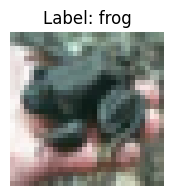

In [48]:
import numpy as np

# We plot a random image from the test set along with its label
index = np.random.randint(0, X_test.shape[0])
plt.figure(figsize=(2, 2))
plt.imshow(X_test[index].reshape(32, 32, 3))
plt.title(f'Label: {class_names[y_test[index].argmax()]}')
plt.axis('off')
plt.show()

And we validate that our model classify that image correctly.

In [56]:
prediction = model.predict(X_test[index].reshape(1, -1))
predicted_class = class_names[prediction.argmax()]
print(f'Actual: {class_names[y_test[index].argmax()]}')
print(f'Predicted: {predicted_class}')
print(f'Prediction confidence: {prediction.max() * 100:.2f}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Actual: frog
Predicted: cat
Prediction confidence: 45.74%


We see that the model is not very accurate, but this is expected given the simplicity of the model and the complexity of the CIFAR-10 dataset. More advanced architectures like Convolutional Neural Networks (CNNs) are typically used for image classification tasks to achieve higher accuracy.

Let's analyze the training process and the results obtained.

In [55]:
from sklearn.metrics import classification_report

predictions = model.predict(X_test, batch_size=150)
training_report = classification_report(y_test.argmax(axis=1), predictions.argmax(axis=1), target_names=class_names)
print(training_report)

67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
              precision    recall  f1-score   support

    airplane       0.75      0.34      0.47      1000
  automobile       0.47      0.79      0.59      1000
        bird       0.49      0.29      0.37      1000
         cat       0.31      0.48      0.37      1000
        deer       0.61      0.17      0.27      1000
         dog       0.58      0.17      0.26      1000
        frog       0.36      0.82      0.50      1000
       horse       0.87      0.29      0.44      1000
        ship       0.59      0.71      0.64      1000
       truck       0.47      0.62      0.54      1000

    accuracy                           0.47     10000
   macro avg       0.55      0.47      0.45     10000
weighted avg       0.55      0.47      0.45     10000



We can see that some classes are classified better than others, in order to visualize this we plot training and validation accuracy and loss over epochs.

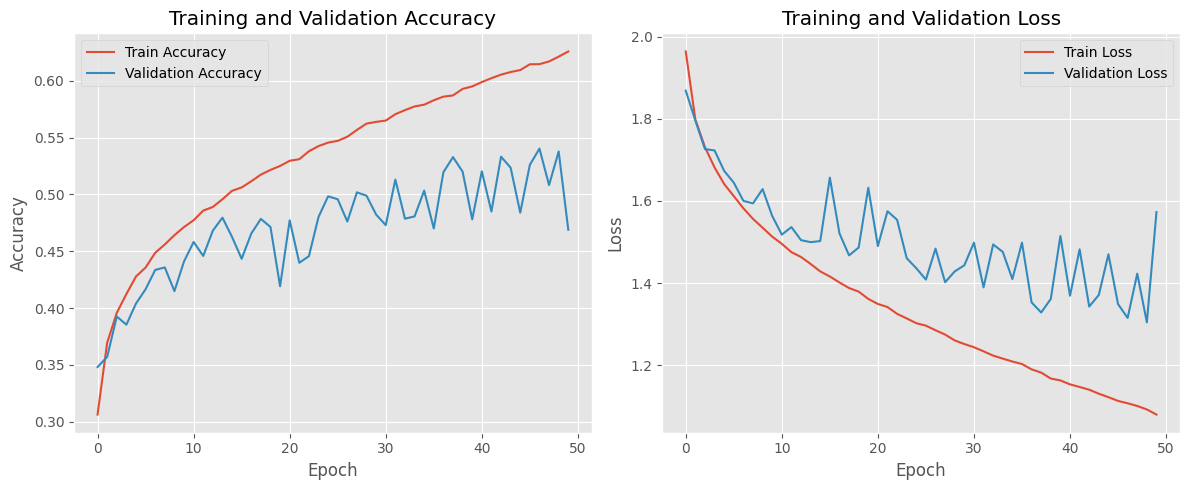

In [59]:
def print_training_metrics(H):
    """Plot training & validation accuracy and loss values"""
    plt.style.use("ggplot")
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(H.history['accuracy'], label='Train Accuracy')
    plt.plot(H.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(H.history['loss'], label='Train Loss')
    plt.plot(H.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

print_training_metrics(H)

Looking at this graphic we can see how our model is learning over time, and if there is overfitting or underfitting happening.

> We see that the model is overfitting, as the training accuracy continues to improve while the validation accuracy plateaus and even decreases after a certain number of epochs. This indicates that the model is learning the training data too well, including its noise and outliers, which negatively impacts its performance on unseen data.

> Same happen with the loss graphic, where training loss decreases while validation loss starts to stagnate after epoch 15, where it still decreases but at a much slower rate and erratically.

Hence increasing number of epochs beyond this point does not improve validation performance and contributes to overfitting.

### How to evolve the model

To mitigate overfitting, we could consider techniques such as dropout, regularization, or using a more complex model architecture.

### Dropout Layers

Dropout is a regularization technique used to prevent overfitting in neural networks. It works by randomly "dropping out" (setting to zero) a fraction of the neurons during training, which forces the network to learn more robust features that are not reliant on any single neuron.

In [60]:
from keras.layers import Dropout

model = Sequential()
model.add(Input(shape=(3072,)))  # Input layer
model.add(Dense(1024, activation='relu'))  # Hidden layer with 1024
model.add(Dropout(0.2))  # Dropout layer with 20% dropout rate
model.add(Dense(512, activation='relu'))   # Hidden layer with 512
model.add(Dropout(0.2))  # Dropout layer with 20% dropout rate
model.add(Dense(10, activation='softmax'))  # Output layer with 10 neurons

20% dropout rate means that during each training iteration, 20% of the neurons will be randomly selected and ignored (dropped out).

In [61]:
opt = SGD(learning_rate=0.01)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
H = model.fit(X_train, y_train, epochs=100, batch_size=150, validation_data=(X_test, y_test))

Epoch 1/100
334/334 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.2622 - loss: 2.0349 - val_accuracy: 0.3363 - val_loss: 1.8761
Epoch 2/100
334/334 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.3392 - loss: 1.8652 - val_accuracy: 0.3835 - val_loss: 1.7773
Epoch 3/100
334/334 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.3648 - loss: 1.7905 - val_accuracy: 0.3888 - val_loss: 1.7323
Epoch 4/100
334/334 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.3841 - loss: 1.7423 - val_accuracy: 0.4092 - val_loss: 1.6926
Epoch 5/100
334/334 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.4013 - loss: 1.7024 - val_accuracy: 0.4232 - val_loss: 1.6497
Epoch 6/100
334/334 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.4107 - loss: 1.6712 - val_accuracy: 0.4301 - val_loss: 1.6405
Epoch 7/100
334/334 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4184 - loss: 1.6443 - val_accuracy: 0.4234 - val_loss: 1.6191
Epoch 8/100
334/334 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4306 - loss: 1.6214 - 

We can see once again the training and validation accuracy and loss over epochs to see if the dropout layers helped reduce overfitting.

In [62]:
from sklearn.metrics import classification_report

predictions = model.predict(X_test, batch_size=150)
training_report = classification_report(y_test.argmax(axis=1), predictions.argmax(axis=1), target_names=class_names)
print(training_report)

67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
              precision    recall  f1-score   support

    airplane       0.77      0.31      0.45      1000
  automobile       0.80      0.49      0.61      1000
        bird       0.29      0.70      0.41      1000
         cat       0.32      0.41      0.36      1000
        deer       0.54      0.35      0.42      1000
         dog       0.46      0.45      0.45      1000
        frog       0.66      0.52      0.58      1000
       horse       0.63      0.58      0.61      1000
        ship       0.58      0.75      0.65      1000
       truck       0.72      0.46      0.56      1000

    accuracy                           0.50     10000
   macro avg       0.58      0.50      0.51     10000
weighted avg       0.58      0.50      0.51     10000



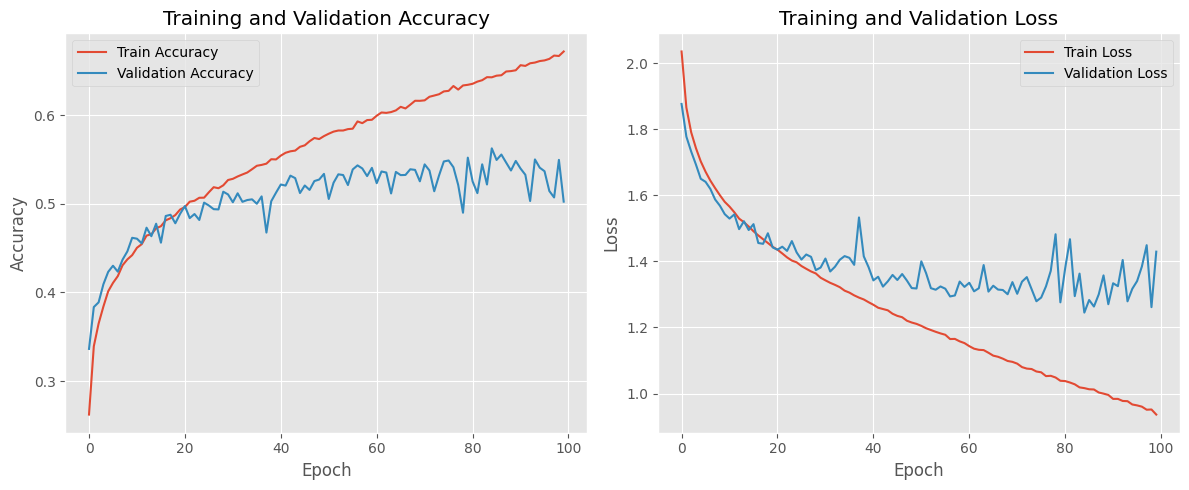

In [63]:
def print_training_metrics(H):
    """Plot training & validation accuracy and loss values"""
    plt.style.use("ggplot")
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(H.history['accuracy'], label='Train Accuracy')
    plt.plot(H.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(H.history['loss'], label='Train Loss')
    plt.plot(H.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

print_training_metrics(H)

After 25 epochs, learning stagnates, indicating that the model has learned as much as it can from the data with the current architecture and hyperparameters.

At this point, we could reevaluate our model architecture, consider adding more layers or neurons, or experiment with different hyperparameters to further improve performance.

But it could also be than the dataset is not good enough for the model to learn more complex patterns.

### Playground

In [64]:
model_pg = Sequential()
model_pg.add(Input(shape=(3072,)))  # Input layer
model_pg.add(Dense(2048, activation='relu'))  # Hidden layer with 2048 neurons
model_pg.add(Dropout(0.3))  # Dropout layer with 30% dropout rate
model_pg.add(Dense(1024, activation='relu'))   # Hidden layer with 1024 neurons
model_pg.add(Dropout(0.3))  # Dropout layer with 30% dropout rate
model_pg.add(Dense(512, activation='relu'))   # Hidden layer with 512 neurons
model_pg.add(Dropout(0.3))  # Dropout layer with 30% dropout rate
model_pg.add(Dense(256, activation='relu'))   # Hidden layer with 256 neurons
model_pg.add(Dropout(0.3))  # Dropout layer with 30% dropout rate
model_pg.add(Dense(128, activation='relu'))   # Hidden layer with 128 neurons
model_pg.add(Dropout(0.3))  # Dropout layer with 30% dropout rate
model_pg.add(Dense(10, activation='softmax'))  # Output layer with 10 neurons

In [65]:
sgd = SGD(learning_rate=0.01)
model_pg.compile(optimizer=sgd, loss='categorical_crossentropy', metrics=['accuracy'])
H_pg = model_pg.fit(X_train, y_train, epochs=50, batch_size=150, validation_data=(X_test, y_test))

Epoch 1/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.1396 - loss: 2.2683 - val_accuracy: 0.2218 - val_loss: 2.1155
Epoch 2/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.1969 - loss: 2.1235 - val_accuracy: 0.2848 - val_loss: 2.0009
Epoch 3/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 22s 66ms/step - accuracy: 0.2376 - loss: 2.0358 - val_accuracy: 0.3024 - val_loss: 1.9267
Epoch 4/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 22s 67ms/step - accuracy: 0.2665 - loss: 1.9718 - val_accuracy: 0.3272 - val_loss: 1.8577
Epoch 5/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - accuracy: 0.2877 - loss: 1.9282 - val_accuracy: 0.3391 - val_loss: 1.8153
Epoch 6/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step - accuracy: 0.3042 - loss: 1.8867 - val_accuracy: 0.3513 - val_loss: 1.7821
Epoch 7/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - accuracy: 0.3171 - loss: 1.8561 - val_accuracy: 0.3088 - val_loss: 1.9193
Epoch 8/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - accuracy: 0.3296 - loss: 1.8297 - 

In [66]:
from sklearn.metrics import classification_report

predictions = model_pg.predict(X_test, batch_size=150)
training_report = classification_report(y_test.argmax(axis=1), predictions.argmax(axis=1), target_names=class_names)
print(training_report)

67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step
              precision    recall  f1-score   support

    airplane       0.55      0.65      0.60      1000
  automobile       0.68      0.66      0.67      1000
        bird       0.36      0.41      0.38      1000
         cat       0.40      0.28      0.33      1000
        deer       0.45      0.44      0.44      1000
         dog       0.52      0.30      0.38      1000
        frog       0.50      0.67      0.57      1000
       horse       0.55      0.65      0.60      1000
        ship       0.67      0.67      0.67      1000
       truck       0.61      0.58      0.59      1000

    accuracy                           0.53     10000
   macro avg       0.53      0.53      0.52     10000
weighted avg       0.53      0.53      0.52     10000



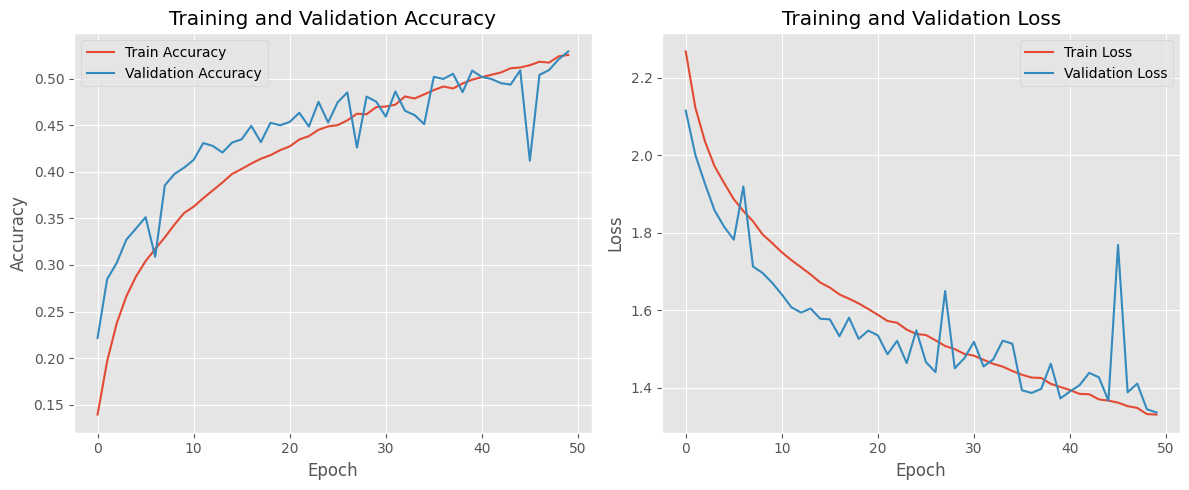

In [67]:
def print_training_metrics(H):
    """Plot training & validation accuracy and loss values"""
    plt.style.use("ggplot")
    plt.figure(figsize=(12, 5))

    # Plot accuracy
    plt.subplot(1, 2, 1)
    plt.plot(H.history['accuracy'], label='Train Accuracy')
    plt.plot(H.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(H.history['loss'], label='Train Loss')
    plt.plot(H.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

print_training_metrics(H_pg)

We reduce ephochs to 50 for faster experimentation. Our new iteration has:
- More hidden layers (5 instead of 2)
- Bigger dropout rate (30% instead of 20%)

Now we see less erratic behavior in validation accuracy and loss, indicating that the model is generalizing better to unseen data.

> Testing set is similar to Training set, so we have to be careful with the conclusions we draw from this.

> It's a good idea writing down the changes made and their effects on model performance for future reference (hyperparameter tuning like learning rate, batch size, number of epochs, etc).

Future labs we will explore more advanced architectures and other techniques to further improve model performance.